In [ ]:
!pip install lightgbm
# !pip install --upgrade lightgbm
!pip install "numpy<2.0"

# Notes for which numpy version to reinstall later
# Found existing installation: numpy 2.0.2
#     Uninstalling numpy-2.0.2:
#       Successfully uninstalled numpy-2.0.2

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import seaborn as sns
import os
import duckdb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)


In [2]:
cleaned_parquet = "../data/cleaned_data/cleaned_fraud.parquet"

print(f"📊 Original size: {os.path.getsize(cleaned_parquet) / (1024**3):.2f} GB")

con = duckdb.connect()

📊 Original size: 0.14 GB


In [3]:
# Load full dataset
df = con.execute(f"SELECT * FROM '{cleaned_parquet}'").fetch_df()

# 1. EDA & Pattern Detection
print("Original Class Distribution:")
print(df['is_fraud'].value_counts(normalize=True))

# Check for negative time values (Pattern Detection)
neg_time = df[df['time_since_last_transaction'] < 0]
print(f"\nRows with negative time_since_last_transaction: {len(neg_time)}")
if len(neg_time) > 0:
    print("Negative values might indicate data errors or specific flags. Treating as valid numeric for now.")
    

con.close()

Original Class Distribution:
is_fraud
False    0.956244
True     0.043756
Name: proportion, dtype: float64

Rows with negative time_since_last_transaction: 2051331
Negative values might indicate data errors or specific flags. Treating as valid numeric for now.


In [ ]:
# We reduce sample size for faster experimentation - 2% of the entire dataset
from sklearn.model_selection import train_test_split

# Desired sample fraction
sample_frac = 0.02  # 2%

# Perform stratified sampling
df_sample, _ = train_test_split(
    df,
    train_size=sample_frac,
    stratify=df['is_fraud'],
    random_state=42
)

print(df_sample.shape)
print(df_sample['is_fraud'].value_counts(normalize=True))

(820697, 20)
is_fraud
False    0.956243
True     0.043757
Name: proportion, dtype: float64


In [5]:
# # df is our full dataset - 30% approach
# fraud = df[df['is_fraud'] == 1]
# legit = df[df['is_fraud'] == 0]

# # Take 30% of fraud cases - Using 30% of true cases
# fraud_30 = fraud.sample(frac=0.30, random_state=42)

# # Sample an equal number of legit cases
# legit_30 = legit.sample(n=len(fraud_30), random_state=42)

# # Combine and shuffle
# df_balanced = pd.concat([fraud_30, legit_30]).sample(frac=1, random_state=42)
# df_balanced

In [6]:
# print(df_sample.shape)
# print(df_sample['is_fraud'].value_counts(normalize=True))

In [7]:


# 2. Data Preparation for SMOTE
# - Drop high cardinality identifiers
# - Encode categorical variables
# - Scale numerical variables

categorical_cols = ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel']
numerical_cols = ['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'hour', 'day_of_week']
drop_cols = ['sender_account', 'receiver_account', 'ip_address', 'device_hash', 'year', 'month', 'day_of_month'] # high-cardinality identifiers that do not generalize well and can negatively affect the model training. Dropping date because we already extracted more meaningful features like hours and days of the week

# Separate Features and Target
X = df.drop(columns=['is_fraud'] + drop_cols, errors='ignore')
y = df['is_fraud']

# Split Data (Best Practice: Split BEFORE SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratifying by y to ensure both splits have an equal amount of the target variable y

# Preprocessing Pipeline 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)



In [8]:
# 4. Full Pipeline: Preprocess → SMOTE → Model - automatic preprocessing applying SMOTE in CV
# Random Forest Classifier with SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

rf_smote_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=3,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))

])


In [9]:
# Using a HalvingGridSearchCV 
# We try many versions of our model with different hyperparameters and uses a successive halving strategy
# - Pick the best hyperparameters overall,  find the best model configuration


from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [120],
    'model__max_depth': [None, 3],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 3],
    'model__max_features': ['sqrt', 'log2']

}

random_search = RandomizedSearchCV(
    estimator=rf_smote_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train) # This takes about x mins to run

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\J2F\anaconda3\envs\dsi_participant\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


: 

: 

In [ ]:
# Best Model
best_pipeline = random_search.best_estimator_
best_pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amount',
                                                   'time_since_last_transaction',
                                                   'spending_deviation_score',
                                                   'velocity_score',
                                                   'geo_anomaly_score', 'hour',
                                                   'day_of_week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'location', 'device_used',
                                                   'payment_channel'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=3, min_samples_leaf=3,
                                        min_samples_split=4, n_estimators=120,
                                        n_jobs=-1, random_state=42))])

In [ ]:
best_hyperparams = random_search.best_params_
best_hyperparams

{'model__max_depth': 3,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 3,
 'model__min_samples_split': 4,
 'model__n_estimators': 120}

In [ ]:
best_score = random_search.best_score_
best_score

0.08171487816416868

              precision    recall  f1-score   support

       False       0.96      0.33      0.49    784787
        True       0.04      0.68      0.08     35911

    accuracy                           0.34    820698
   macro avg       0.50      0.50      0.28    820698
weighted avg       0.92      0.34      0.47    820698



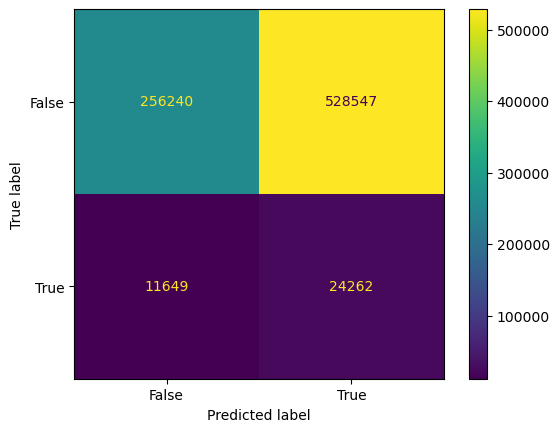

In [ ]:
# Evaluate on the realistic test set

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

#  PRediction
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

F1 Score: 0.08242288354395978
Precision: 0.04388857634372812
Recall: 0.6756147141544374
PR AUC: 0.044065245525415825

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.33      0.49    784787
        True       0.04      0.68      0.08     35911

    accuracy                           0.34    820698
   macro avg       0.50      0.50      0.28    820698
weighted avg       0.92      0.34      0.47    820698

ROC AUC: 0.4990914069099841


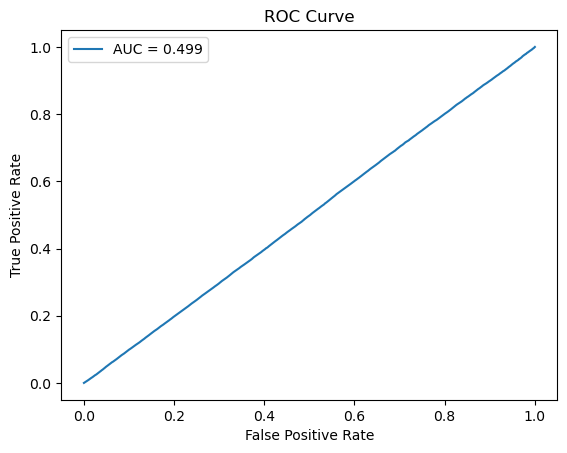

In [ ]:
# Evaluate Probability-Based Metrics 
# ROC Curve and AUC

from sklearn.metrics import roc_curve, auc

y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# --- Classification Metrics ---
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

# --- PR AUC ---
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)
print("PR AUC:", pr_auc)

# Optional: full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- ROC AUC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)


plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

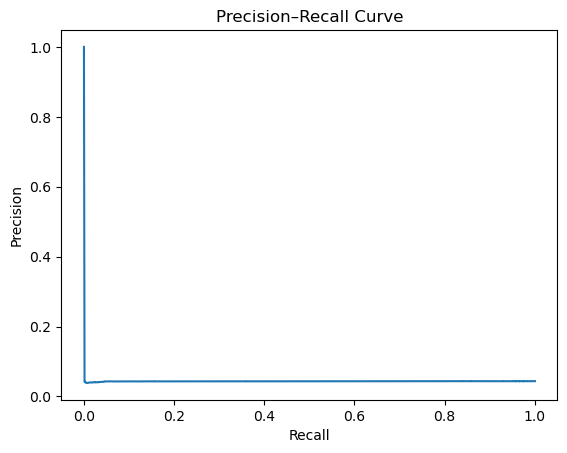

In [ ]:
# Precision–Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [ ]:
# Bootstrapping for Confidence Intervals
import numpy as np
from sklearn.metrics import f1_score

boot_scores = []

for i in range(1000):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    boot_scores.append(f1_score(y_test.iloc[idx], y_pred[idx]))
    # or y_pred.iloc[idx] if y_pred is also a Series

ci_low = np.percentile(boot_scores, 2.5)
ci_high = np.percentile(boot_scores, 97.5)

ci_low, ci_high

(0.08150122255425292, 0.08341106430545114)